=== Integrity Summary ===
• index_min: 2017-08-17 04:00:00+00:00
• index_max: 2025-01-09 16:00:00+00:00
• rows: 64861
• cols: 121
• duplicate_timestamps: 0
• missing_grid_slots: 0
• missing_close_rows: 132

Top NaN columns:
sent_Short Description      64861
date                        64861
hash-rate                   64861
hash_asof_date              64861
momentum_pvo                59401
momentum_pvo_signal         59401
momentum_pvo_hist           59401
sent_asof_date              37004
sent_Accurate Sentiments    37004
trend_psar_down             33553
trend_psar_up               31442
sma200                        331
dtype: int64


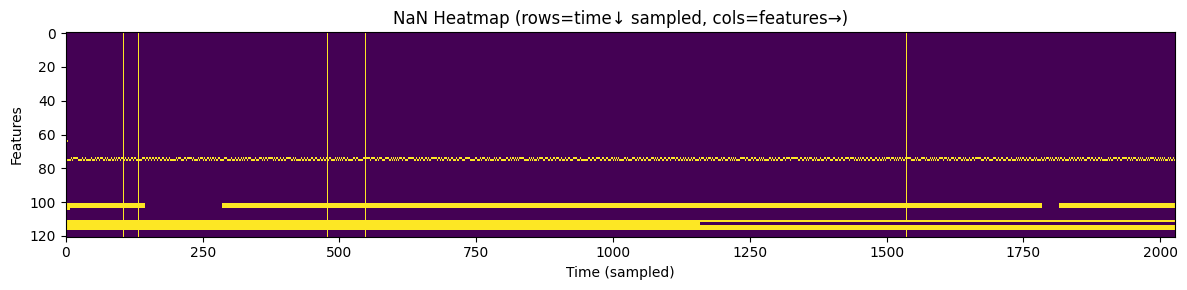

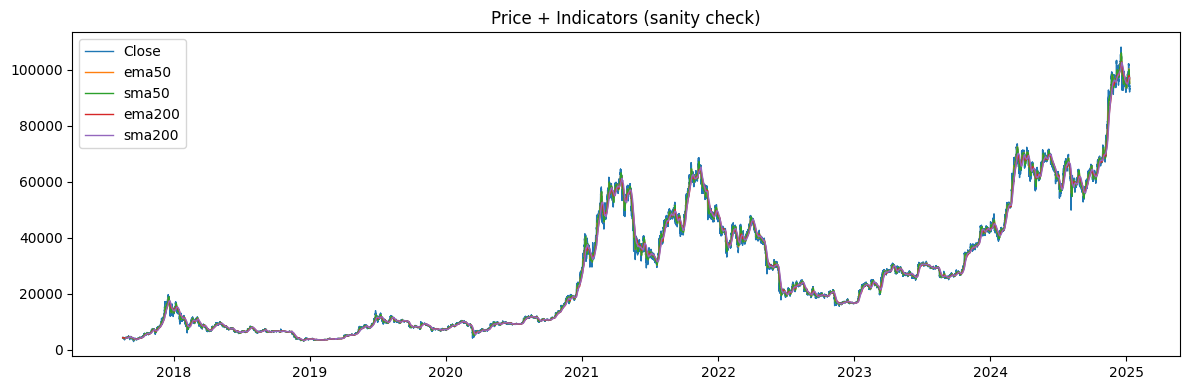

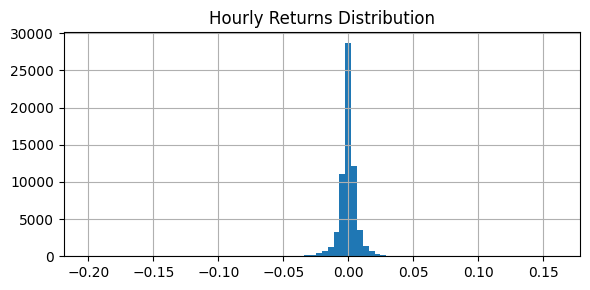

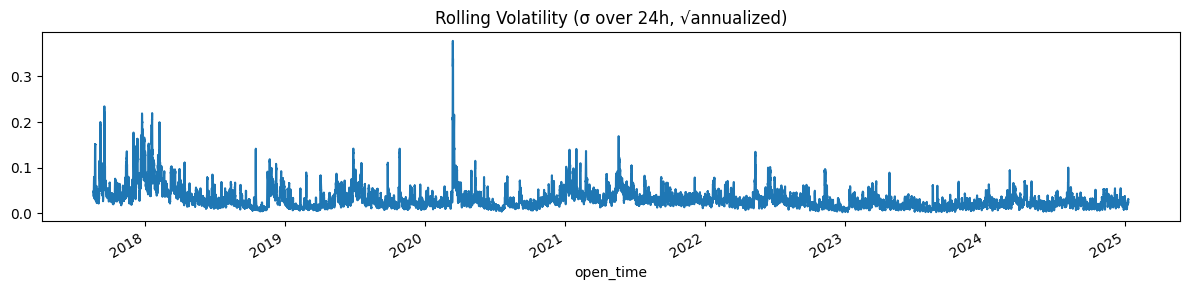

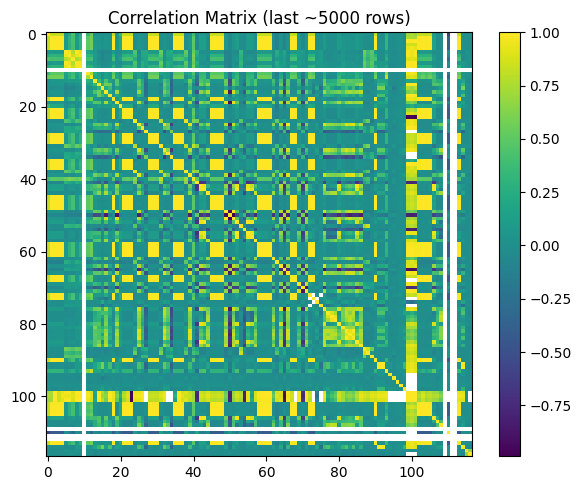

Correlation ema50(t) vs target y_ret_t1(t+1): -0.003108

Saved figures → data/out/figures
Saved diagnostics → data/out/diagnostics


In [1]:
# =========================
# Step 2: Integrity checks & EDA on ETL output
# Saves figures & tables for your DOCX
# =========================
import os
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Paths --------
IN_PARQ = "data/out/btc_master_hourly_2017_2025.parquet"
IN_CSV  = "data/out/btc_master_hourly_2017_2025.csv"

DIR_FIG = "data/out/figures"
DIR_DIA = "data/out/diagnostics"
os.makedirs(DIR_FIG, exist_ok=True)
os.makedirs(DIR_DIA, exist_ok=True)

# -------- Load dataset --------
def _try_load_master():
    if os.path.exists(IN_PARQ):
        df = pd.read_parquet(IN_PARQ)
        # Parquet preserves index; ensure it's datetime
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index, utc=True)
        return df
    elif os.path.exists(IN_CSV):
        df = pd.read_csv(IN_CSV)
        # Try to find datetime column or index column written by to_csv
        dt_col = None
        for c in ["open_time", "timestamp", "date", "datetime", "time", "Date"]:
            if c in df.columns:
                dt_col = c; break
        # If first column is unnamed, assume it's the saved index
        if dt_col is None:
            first = df.columns[0]
            if first.lower().startswith("unnamed"):
                dt_col = first
        if dt_col is None:
            raise ValueError("Could not identify datetime column in CSV.")
        df[dt_col] = pd.to_datetime(df[dt_col], utc=True)
        df = df.sort_values(dt_col).set_index(dt_col)
        return df
    else:
        raise FileNotFoundError("Master dataset not found. Expected Parquet or CSV in data/out/.")

df = _try_load_master()

# -------- Integrity report --------
def integrity_report(frame: pd.DataFrame, index_freq="1H", max_list=12):
    idx_min, idx_max = frame.index.min(), frame.index.max()
    full_range = pd.date_range(idx_min, idx_max, freq=index_freq, tz=frame.index.tz)
    missing_grid_slots = len(full_range.difference(frame.index))  # should be 0 after asfreq
    dups = frame.index.duplicated().sum()
    n_rows, n_cols = frame.shape

    # Top NaN columns
    nan_counts = frame.isna().sum().sort_values(ascending=False)
    top_nan = nan_counts[nan_counts > 0].head(max_list)

    # Where hourly bars exist but 'close' is missing (useful proxy for raw feed gaps)
    missing_close_rows = int(frame["close"].isna().sum()) if "close" in frame.columns else None

    rep = {
        "index_min": str(idx_min),
        "index_max": str(idx_max),
        "rows": int(n_rows),
        "cols": int(n_cols),
        "duplicate_timestamps": int(dups),
        "missing_grid_slots": int(missing_grid_slots),
        "missing_close_rows": int(missing_close_rows) if missing_close_rows is not None else None,
    }
    # Save a text/CSV snapshot for the dissertation appendix
    pd.Series(rep).to_csv(os.path.join(DIR_DIA, "integrity_summary.csv"))
    top_nan.to_csv(os.path.join(DIR_DIA, "top_nan_columns.csv"))
    print("=== Integrity Summary ===")
    for k, v in rep.items():
        print(f"• {k}: {v}")
    if len(top_nan) > 0:
        print("\nTop NaN columns:")
        print(top_nan)

integrity_report(df)

# -------- Longest NaN streak per column --------
def longest_nan_streak(s: pd.Series) -> int:
    isn = s.isna().to_numpy()
    if not isn.any(): return 0
    max_streak = curr = 0
    for v in isn:
        if v:
            curr += 1
            max_streak = max(max_streak, curr)
        else:
            curr = 0
    return max_streak

nan_streaks = {c: longest_nan_streak(df[c]) for c in df.columns}
nan_streaks = pd.Series(nan_streaks).sort_values(ascending=False)
nan_streaks.to_csv(os.path.join(DIR_DIA, "longest_nan_streaks.csv"))

# -------- NaN heatmap (downsampled for speed) --------
plt.figure(figsize=(12, 3))
# Downsample rows to ~2000 points so rendering is fast
step = max(1, len(df) // 2000)
mask = df.isna().to_numpy()[::step, :].T  # (features x time)
plt.imshow(mask, aspect="auto", interpolation="nearest")
plt.title("NaN Heatmap (rows=time↓ sampled, cols=features→)")
plt.xlabel("Time (sampled)")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIG, "step2_nan_heatmap.png"), dpi=160)
plt.show()

# -------- Price + indicators overlay (if present) --------
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["close"], label="Close", linewidth=1)
for c in ["ema50","sma50","ema200","sma200"]:
    if c in df.columns:
        plt.plot(df.index, df[c], label=c, linewidth=1)
plt.title("Price + Indicators (sanity check)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(DIR_FIG, "step2_price_overlay.png"), dpi=160)
plt.show()

# -------- Returns distribution & rolling volatility --------
if "ret_t" in df.columns:
    plt.figure(figsize=(6, 3))
    df["ret_t"].dropna().hist(bins=80)
    plt.title("Hourly Returns Distribution")
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_FIG, "step2_returns_distribution.png"), dpi=160)
    plt.show()

    vol_window = 24  # 24h rolling std (hourly data)
    plt.figure(figsize=(12, 3))
    (df["ret_t"].rolling(vol_window).std() * np.sqrt(vol_window)).dropna().plot()
    plt.title(f"Rolling Volatility (σ over {vol_window}h, √annualized)")
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_FIG, "step2_rolling_volatility.png"), dpi=160)
    plt.show()

# -------- Correlation snapshot (last ~5000 rows, numeric only) --------
sample = df.select_dtypes(include=[np.number]).dropna(how="all").tail(5000)
if not sample.empty:
    corr = sample.corr()
    plt.figure(figsize=(6, 5))
    plt.imshow(corr, aspect="auto", interpolation="nearest")
    plt.title("Correlation Matrix (last ~5000 rows)")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_FIG, "step2_correlation_matrix.png"), dpi=160)
    plt.show()
    corr.to_csv(os.path.join(DIR_DIA, "corr_last5k_numeric.csv"))

# -------- Alignment sanity: corr[ema50(t), y_ret_t1] --------
if "ema50" in df.columns and "y_ret_t1" in df.columns:
    aligned = df[["ema50", "y_ret_t1"]].dropna()
    rho = aligned["ema50"].corr(aligned["y_ret_t1"])
    print(f"Correlation ema50(t) vs target y_ret_t1(t+1): {rho:.6f}")
    aligned.head(3).to_csv(os.path.join(DIR_DIA, "alignment_head.csv"))

print("\nSaved figures →", DIR_FIG)
print("Saved diagnostics →", DIR_DIA)
